In [24]:
import os
import cv2
import numpy as np
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt
from glob import glob
import pandas as pd
from collections import defaultdict
import itertools
import csv

In [2]:
def draw_contours(image, contours, labels=None):
    boxed = image.copy()
    for i, cnt in enumerate(contours):
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(boxed, (x, y), (x + w, y + h), (0, 255, 0), 3)
        if labels and i < len(labels):
            cv2.putText(boxed, labels[i], (x, y + 40), cv2.FONT_HERSHEY_SIMPLEX,
                        2.0, (0, 0, 255), 4, lineType=cv2.LINE_AA)
    return boxed



In [3]:
# --------- Step 1: K-means Color Clustering ---------
def kmeans_clustering(image, k=4):
    Z = image.reshape((-1, 3))
    Z = np.float32(Z)
    kmeans = KMeans(n_clusters=k, random_state=0).fit(Z)
    labels = kmeans.labels_.reshape(image.shape[:2])
    clustered_img = kmeans.cluster_centers_[labels].reshape(image.shape).astype(np.uint8)
    return clustered_img, labels

In [4]:
def extract_class_masks(labels, num_classes=4):
    masks = []
    for i in range(num_classes):
        mask = np.uint8(labels == i) * 255
        masks.append(mask)
    return masks

In [5]:
def clean_mask(mask):
    # Larger kernels to suppress small dots and merge nearby blobs
    kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))

    opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel_open)
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel_close)
    
    # Optional: strengthen structure further
    dilated = cv2.dilate(closed, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7)), iterations=1)
    return dilated

In [6]:
def get_contours_from_mask(mask, min_area=1500, size_range=(450, 700)): #Change here 450 to 700
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filtered = []
    for c in contours:
        x, y, w, h = cv2.boundingRect(c)
        if (min_area < cv2.contourArea(c) and
            size_range[0] <= w <= size_range[1] and
            size_range[0] <= h <= size_range[1]):
            filtered.append(c)
    return filtered

In [7]:
# --------- Step 3: Histogram Extraction ---------
def extract_histogram(img, contour):
    x, y, w, h = cv2.boundingRect(contour)
    roi = img[y:y+h, x:x+w]
    hist = cv2.calcHist([roi], [0, 1, 2], None, [8,8,8], [0,256,0,256,0,256])
    cv2.normalize(hist, hist)
    return hist.flatten()

def match_histogram(hist, reference_histograms):
    return max(reference_histograms.items(),
               key=lambda item: cv2.compareHist(hist, item[1], cv2.HISTCMP_CORREL))[0]

In [45]:
def load_reference_histograms_from_annotations(csv_path, train_folder):
    df = pd.read_csv(csv_path)

    # To store histograms per class
    histograms_by_class = defaultdict(list)

    for _, row in df.iterrows():
        filename = row['filename']
        img_path = os.path.join(train_folder, filename)
        img = cv2.imread(img_path)
        if img is None:
            print(f"Warning: Failed to load image {img_path}")
            continue

        x_min, y_min, x_max, y_max = int(row['xmin']), int(row['ymin']), int(row['xmax']), int(row['ymax'])
        cls = row['class']

        # Crop region and extract histogram
        roi = img[y_min:y_max, x_min:x_max]
        if roi.size == 0:
            print(f"Warning: Empty ROI for {filename} {cls}")
            continue

        hist = cv2.calcHist([roi], [0, 1, 2], None, [8,8,8], [0,256,0,256,0,256])
        cv2.normalize(hist, hist)
        histograms_by_class[cls].append(hist.flatten())

    # Compute mean histogram per class
    mean_histograms = {}
    for cls, hist_list in histograms_by_class.items():
        mean_hist = np.mean(hist_list, axis=0)
        mean_histograms[cls] = mean_hist

    print(f"Computed histograms for {len(mean_histograms)} classes.")
    return mean_histograms


In [51]:
# --------- Visualization ---------
def display_results(orig, clustered, contours, labels):
    clustered_boxes = draw_contours(clustered, contours)
    original_boxes = draw_contours(orig.copy(), contours)
    labeled_img = draw_contours(orig.copy(), contours, labels)

    fig, axs = plt.subplots(1, 3, figsize=(20, 8))  # Slightly larger figure
    axs[0].imshow(cv2.cvtColor(clustered_boxes, cv2.COLOR_BGR2RGB))
    axs[0].set_title('K-means with BBoxes', fontsize=24)
    axs[1].imshow(cv2.cvtColor(original_boxes, cv2.COLOR_BGR2RGB))
    axs[1].set_title('Original with BBoxes', fontsize=24)
    axs[2].imshow(cv2.cvtColor(labeled_img, cv2.COLOR_BGR2RGB))
    axs[2].set_title('Final Classification', fontsize=24)

    for ax in axs:
        ax.axis('off')

    plt.tight_layout()
    plt.show()



In [43]:
# --------- Histogram Matching with Object Filtering ---------
def match_histogram_dual(hist, ref_chocolates, ref_objects):
    best_label = None
    best_score = -1

    # Compare to chocolate reference histograms
    for label, ref_hist in ref_chocolates.items():
        score = cv2.compareHist(hist, ref_hist, cv2.HISTCMP_CORREL)
        if score > best_score:
            best_score = score
            best_label = label
            best_from = 'chocolate'

    # Compare to object reference histograms
    for label, ref_hist in ref_objects.items():
        score = cv2.compareHist(hist, ref_hist, cv2.HISTCMP_CORREL)
        if score > best_score:
            best_score = score
            best_label = label
            best_from = 'object'

    # Only return label if it matched a chocolate, not an object
    return best_label if best_from == 'chocolate' else None


In [49]:
def process_image_kmeans_only(img_path, reference_histograms, reference_histograms_objects):
    img = cv2.imread(img_path)
    clustered_img, labels = kmeans_clustering(img, k=4)
    class_masks = extract_class_masks(labels)

    all_contours = []
    all_labels = []

    for mask in class_masks:
        cleaned = clean_mask(mask)
        contours = get_contours_from_mask(cleaned)
        for cnt in contours:
            hist = extract_histogram(img, cnt)
            best_label = match_histogram_dual(hist, reference_histograms, reference_histograms_objects)
            if best_label:  # Only add if it's from the chocolate set
                all_contours.append(cnt)
                all_labels.append(best_label)

    display_results(img, clustered_img, all_contours, all_labels)


In [ ]:
# # --------- Step 5: Histogram Comparison ---------
# def match_histogram(hist, reference_histograms):
#     scores = {cls: cv2.compareHist(hist, ref, cv2.HISTCMP_CORREL) for cls, ref in reference_histograms.items()}
#     return max(scores, key=scores.get)

# # --------- Step 6: Run Full Pipeline on Image ---------
# def process_image_kmeans_only(img_path, reference_histograms):
#     img = cv2.imread(img_path)
#     clustered_img, labels = kmeans_clustering(img, k=4)
#     class_masks = extract_class_masks(labels)

#     all_contours = []
#     all_labels = []

#     for mask in class_masks:
#         cleaned = clean_mask(mask)
#         contours = get_contours_from_mask(cleaned)
#         for cnt in contours:
#             hist = extract_histogram(img, cnt)
#             best_label = match_histogram(hist, reference_histograms)
#             all_contours.append(cnt)
#             all_labels.append(best_label)
            
#     display_results(img, clustered_img, cleaned, all_contours, all_labels)

In [46]:
ref_histograms = load_reference_histograms_from_annotations(r'data\_annotations.csv', r'images\train_total')
ref_object_histograms = load_reference_histograms_from_annotations(r'data\_annotations_objects.csv', r'images\train_total')

Computed histograms for 13 classes.
Computed histograms for 34 classes.


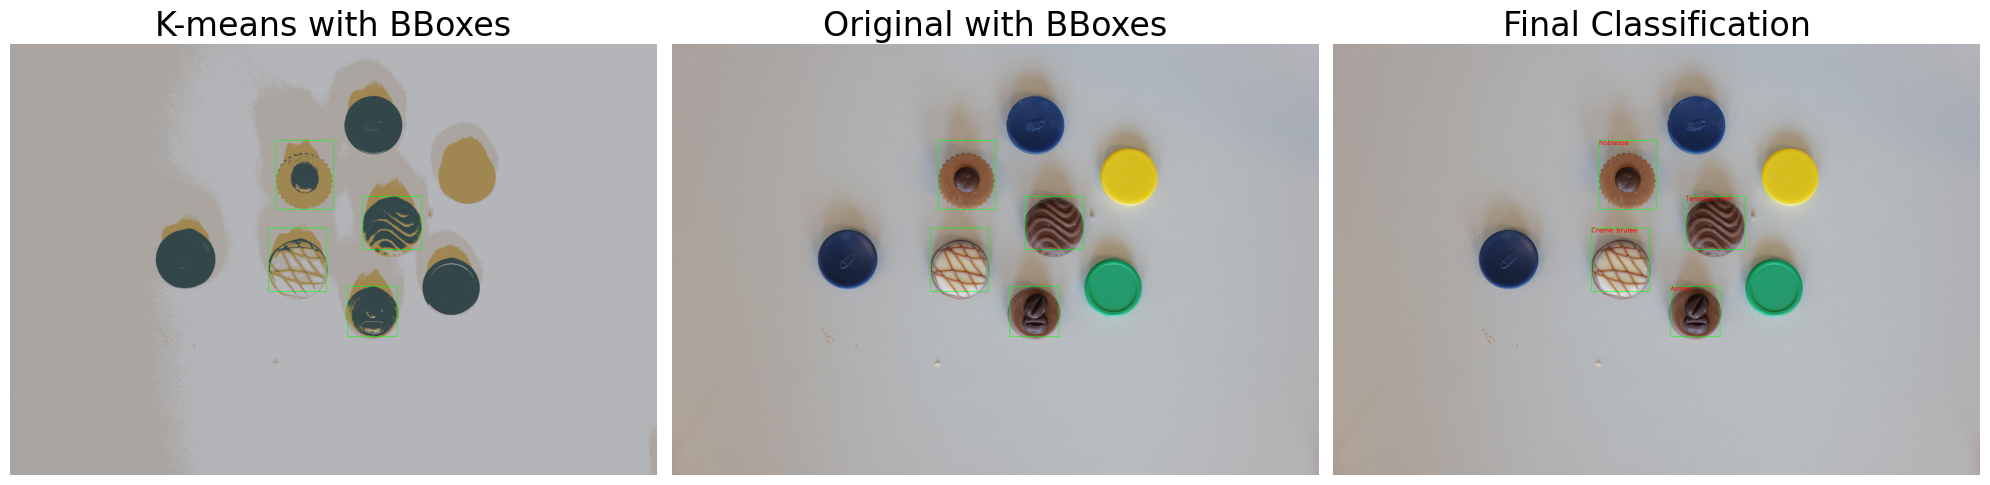

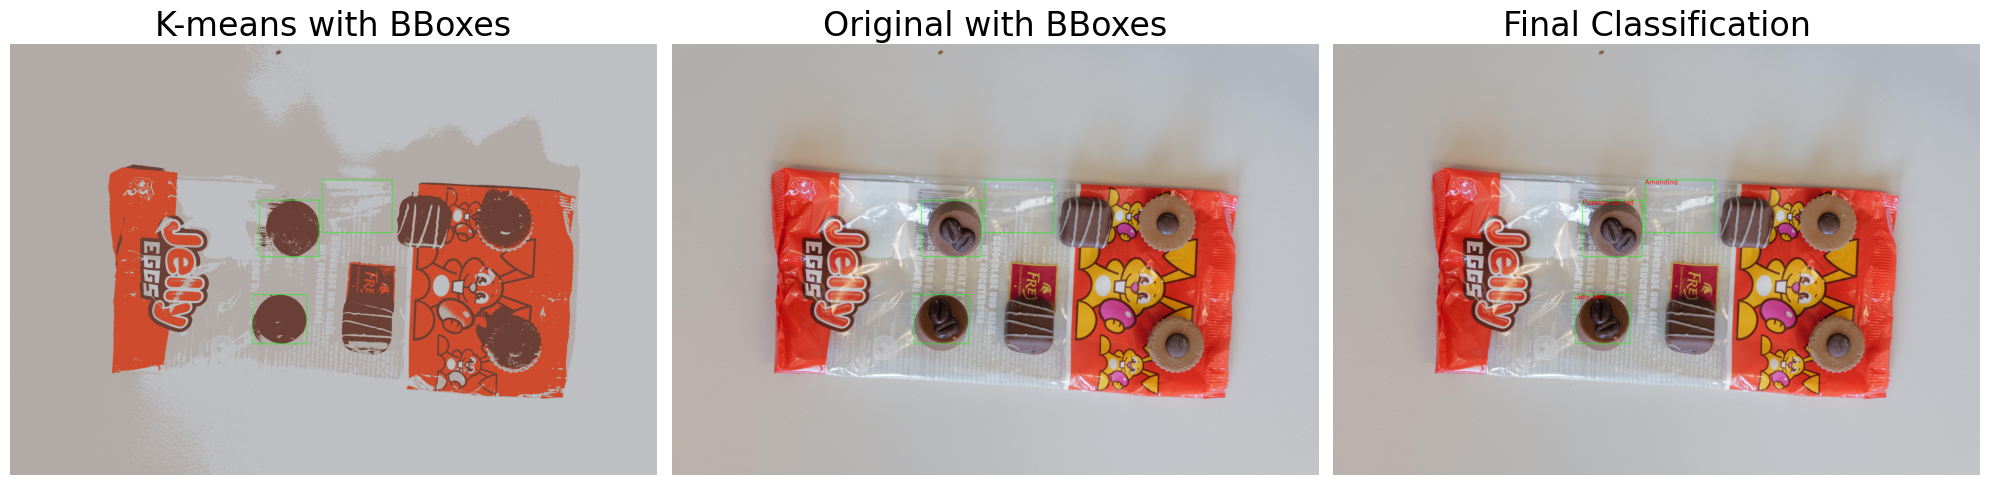

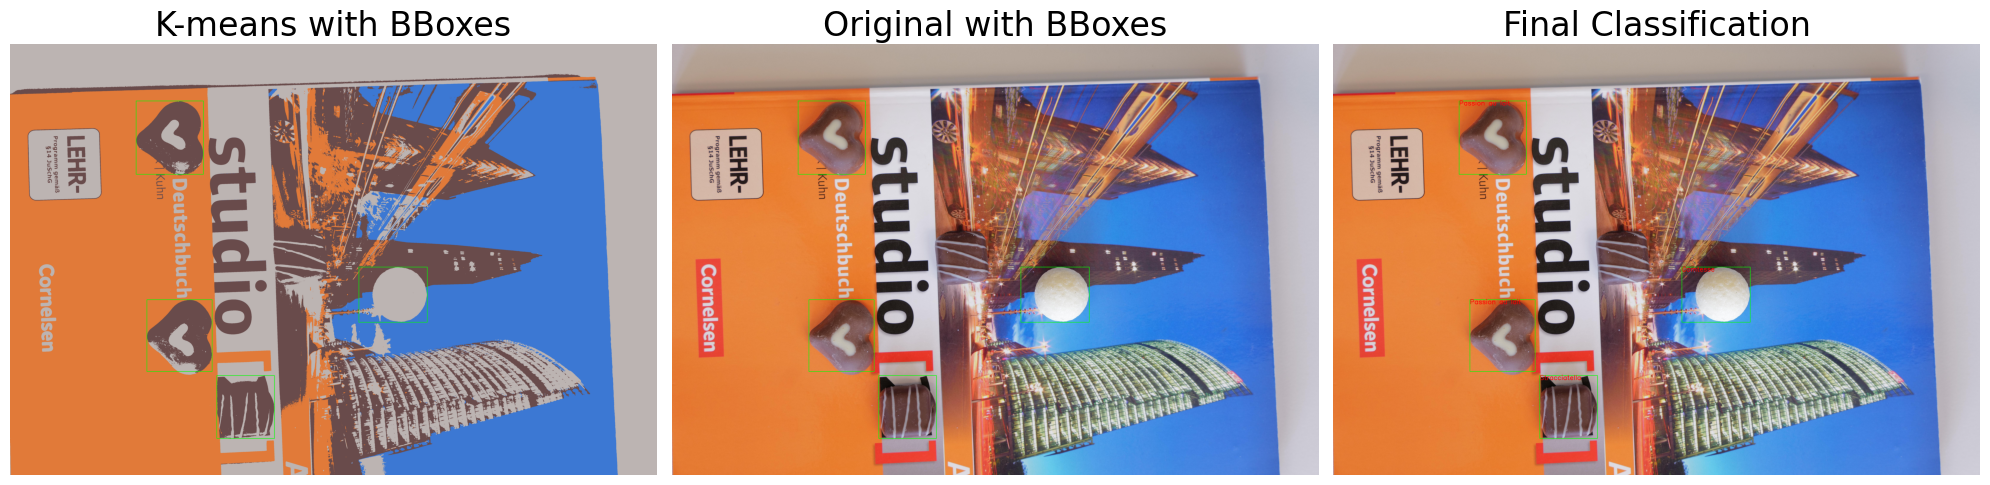

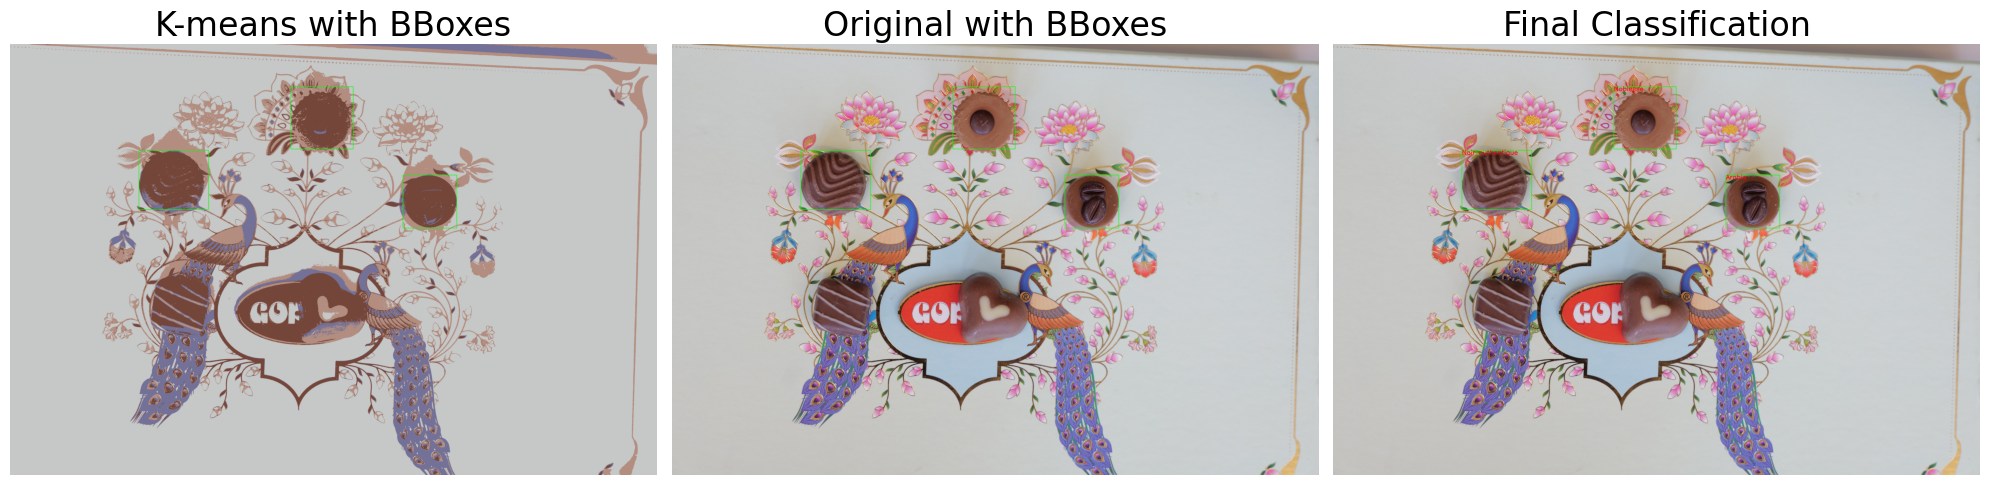

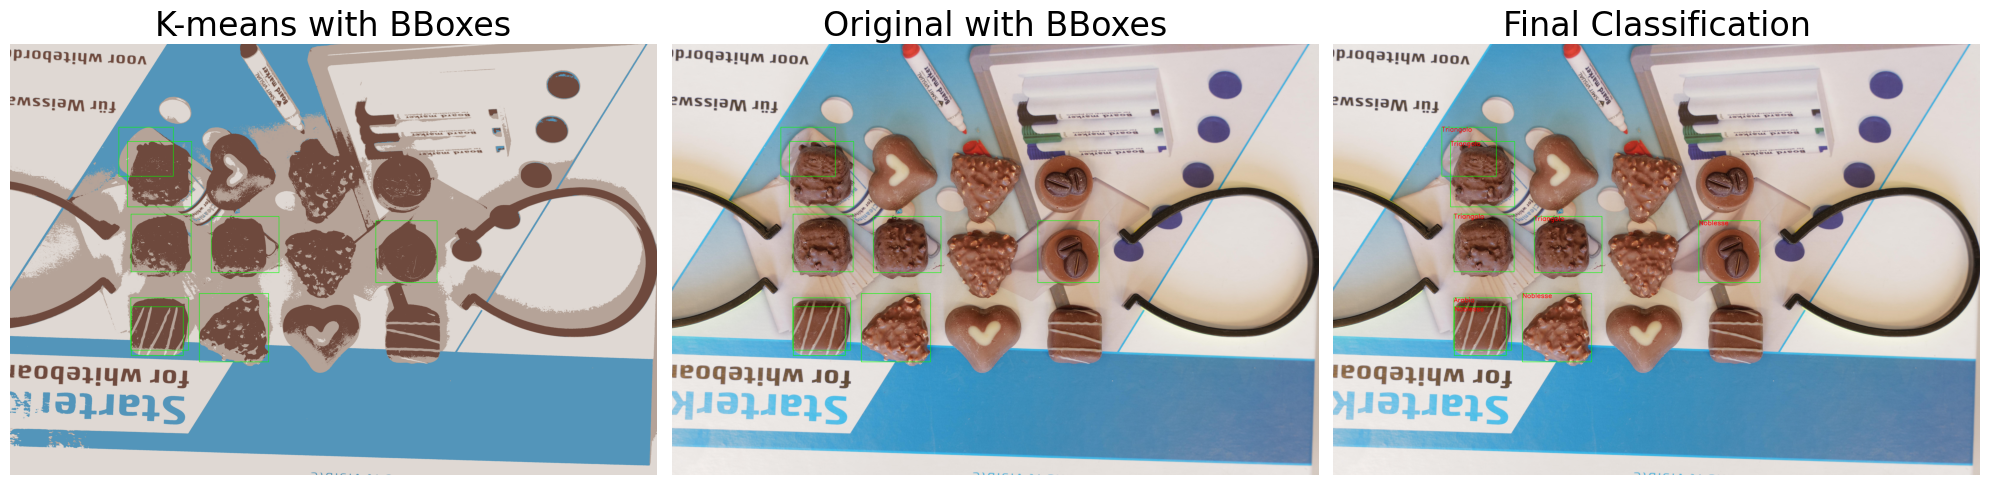

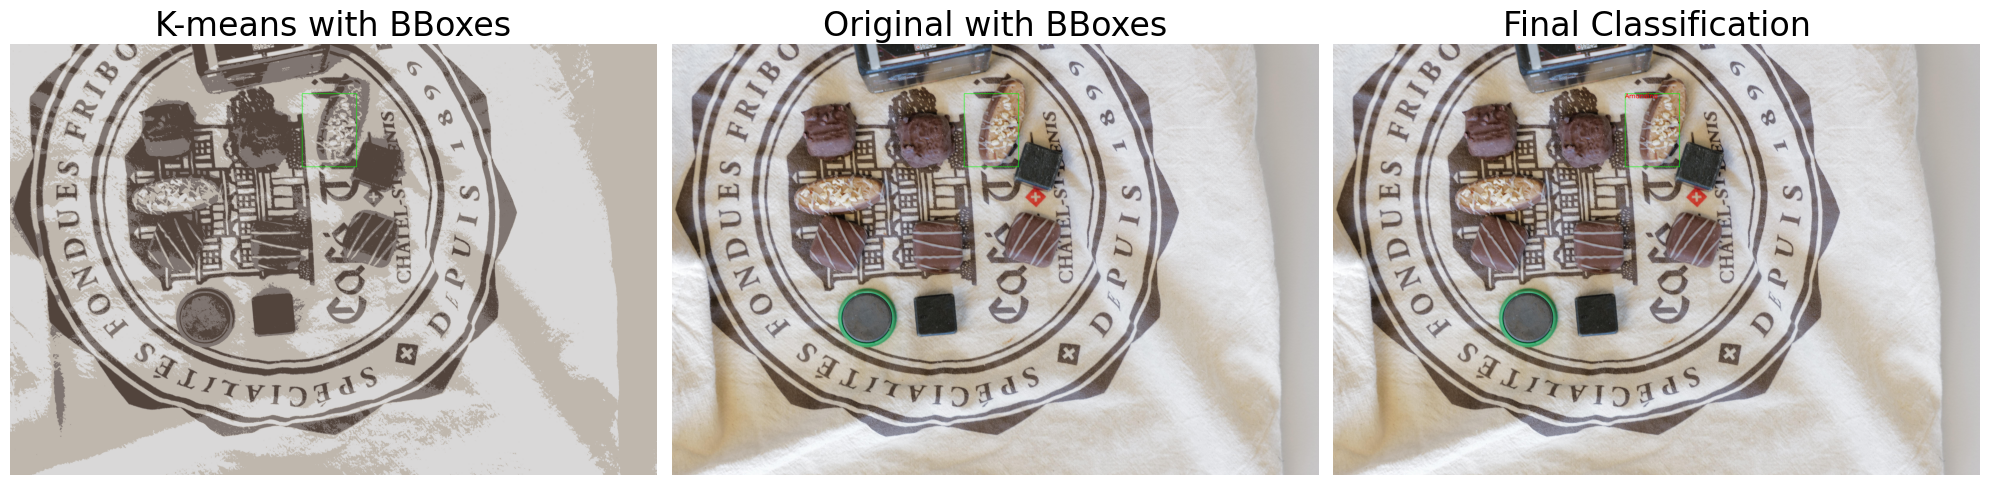

In [59]:
# test_folder = r'images\test_small'
test_folder = r'images\valid_small\diff_backgrounds'
for img_path in glob(os.path.join(test_folder, "*.jpg")):
    process_image_kmeans_only(img_path, ref_histograms, ref_object_histograms)

## Generate CSV

Must adapt the names, had to be done by hand

In [54]:
import itertools

def compute_overlap_ratio(box1, box2):
    # (x, y, w, h)
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2

    # Convert to x_min, y_min, x_max, y_max
    xa1, ya1, xa2, ya2 = x1, y1, x1 + w1, y1 + h1
    xb1, yb1, xb2, yb2 = x2, y2, x2 + w2, y2 + h2

    # Compute intersection
    xi1 = max(xa1, xb1)
    yi1 = max(ya1, yb1)
    xi2 = min(xa2, xb2)
    yi2 = min(ya2, yb2)

    iw = max(0, xi2 - xi1)
    ih = max(0, yi2 - yi1)
    inter_area = iw * ih

    area1 = w1 * h1
    area2 = w2 * h2
    overlap_ratio = inter_area / min(area1, area2) if min(area1, area2) > 0 else 0


    return overlap_ratio

def filter_overlapping_boxes(detections, overlap_thresh=0.1):
    keep = [True] * len(detections)

    for i, j in itertools.combinations(range(len(detections)), 2):
        if not keep[i] or not keep[j]:
            continue

        boxA = detections[i]['bbox']
        boxB = detections[j]['bbox']
        overlap = compute_overlap_ratio(boxA, boxB)

        if overlap >= overlap_thresh:
            # Compare scores
            if detections[i]['score'] >= detections[j]['score']:
                keep[j] = False
            else:
                keep[i] = False

    return [det for k, det in enumerate(detections) if keep[k]]




In [55]:
# Expected labels (MUST match what your `load_reference_histograms` returns!)
EXPECTED_LABELS = [
    "Jelly White", "Jelly Milk", "Jelly Black", "Amandina", "Creme brulee",
    "Triangolo", "Tentation noir", "Comtesse", "Noblesse", "Noir authentique",
    "Passion au lait", "Arabia", "Stracciatella"
]

def process_image_for_counts(img_path, reference_histograms):
    img = cv2.imread(img_path)
    if img is None:
        print(f"Error loading image: {img_path}")
        return None

    clustered_img, labels = kmeans_clustering(img, k=4)
    class_masks = extract_class_masks(labels)

    detected = []
    detected = filter_overlapping_boxes(detected, overlap_thresh=0.1)


    for mask in class_masks:
        cleaned = clean_mask(mask)
        contours = get_contours_from_mask(cleaned)
        for cnt in contours:
            x, y, w, h = cv2.boundingRect(cnt)
            roi = img[y:y+h, x:x+w]
            if roi.size == 0:
                continue
            hist = extract_histogram(img, cnt)
            best_label = match_histogram(hist, reference_histograms)
            score = cv2.compareHist(hist, reference_histograms[best_label], cv2.HISTCMP_CORREL)
            detected.append({
                'contour': cnt,
                'label': best_label,
                'score': score,
                'bbox': (x, y, x + w, y + h),
            })

    # --------- Overlap filtering ---------
    keep = [True] * len(detected)
    for i, j in itertools.combinations(range(len(detected)), 2):
        if not keep[i] or not keep[j]:
            continue
        boxA, boxB = detected[i]['bbox'], detected[j]['bbox']
        overlap = compute_overlap_ratio(boxA, boxB)
        if overlap >= 0.1:
            if detected[i]['score'] >= detected[j]['score']:
                keep[j] = False
            else:
                keep[i] = False

    # --------- Count final labels ---------
    counts = {label: 0 for label in EXPECTED_LABELS}
    for i, d in enumerate(detected):
        if keep[i] and d['label'] in counts:
            counts[d['label']] += 1

    return counts


In [56]:
def generate_csv(test_folder, reference_histograms, output_csv):
    with open(output_csv, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['id'] + EXPECTED_LABELS)  # Header

        for img_path in glob(os.path.join(test_folder, '*.jpg')):
            filename = os.path.basename(img_path)

            # New ID extraction logic
            if filename.lower().startswith('l') and filename.lower().endswith('.jpg'):
                img_id = filename[1:filename.lower().rindex('.')]  # e.g., L1000757.JPG → 1000757
            else:
                print(f"Unexpected filename format: {filename}")
                continue

            counts = process_image_for_counts(img_path, reference_histograms)
            if counts is not None:
                row = [img_id] + [counts[label] for label in EXPECTED_LABELS]
                writer.writerow(row)
                print(f"Processed: {img_id}")



In [58]:
ref_histograms = load_reference_histograms_from_annotations(r'data\_annotations.csv', r'images\train_total')
generate_csv(
    test_folder=r'images\test',
    reference_histograms=ref_histograms,
    output_csv='chocolate_counts3.csv'
)


Computed histograms for 13 classes.
Processed: 1000757
Processed: 1000758
Processed: 1000759
Processed: 1000760
Processed: 1000761
Processed: 1000762
Processed: 1000764
Processed: 1000766
Processed: 1000767
Processed: 1000769
Processed: 1000770
Processed: 1000773
Processed: 1000774
Processed: 1000775
Processed: 1000776
Processed: 1000777
Processed: 1000778
Processed: 1000781
Processed: 1000782
Processed: 1000783
Processed: 1000784
Processed: 1000786
Processed: 1000789
Processed: 1000790
Processed: 1000794
Processed: 1000795
Processed: 1000796
Processed: 1000798
Processed: 1000800
Processed: 1000801
Processed: 1000806
Processed: 1000807
Processed: 1000809
Processed: 1000811
Processed: 1000813
Processed: 1000814
Processed: 1000816
Processed: 1000818
Processed: 1000819
Processed: 1000822
Processed: 1000823
Processed: 1000824
Processed: 1000825
Processed: 1000829
Processed: 1000830
Processed: 1000832
Processed: 1000833
Processed: 1000834
Processed: 1000835
Processed: 1000837
Processed: 100